# ResNet18_4.0 - Red neuronal mejorada con Optuna

Notebook modular basado en la estructura de bloques del `ResNet18.ipynb`, con una arquitectura residual mejorada (bloques SE), pipeline de datos más robusto y búsqueda de hiperparámetros con **Optuna**.


In [1]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import optuna


## Carga y análisis del dataset


In [2]:
x_path = "X_train.npz"
y_path = "Y_train.npz"


def cargar_npz(ruta):
    data = np.load(ruta)
    if isinstance(data, np.lib.npyio.NpzFile):
        if len(data.files) == 0:
            raise ValueError(f"El archivo {ruta} no contiene arrays")
        arr = data[data.files[0]]
        data.close()
        return arr
    return data


X = cargar_npz(x_path)
Y = cargar_npz(y_path)

IMAGE_HEIGHT = 80
IMAGE_WIDTH = 70
IMAGE_SIZE = IMAGE_HEIGHT * IMAGE_WIDTH

if X.ndim != 2 or X.shape[1] != IMAGE_SIZE:
    raise ValueError(f"Se esperaba X con shape [N, {IMAGE_SIZE}] y llegó {X.shape}")

if Y.ndim != 1:
    Y = Y.reshape(-1)

classes, counts = np.unique(Y, return_counts=True)
N_CLASSES = len(classes)

print("Shape X:", X.shape)
print("Shape Y:", Y.shape)
print("N_CLASSES:", N_CLASSES)
print("Min/Max muestras por clase:", counts.min(), counts.max())
print("Distribución balanceada:", bool(np.all(counts == counts[0])))


Shape X: (240, 5600)
Shape Y: (240,)
N_CLASSES: 40
Min/Max muestras por clase: 6 6
Distribución balanceada: True


## División estratificada y pipeline de augmentación

Se mantiene la filosofía modular por bloques: funciones separadas para división, normalización y datasets.


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


def stratified_split_indices(labels, train_ratio=0.75, seed=42):
    rng = np.random.default_rng(seed)
    train_idx = []
    test_idx = []

    for cls in np.unique(labels):
        idx = np.where(labels == cls)[0]
        rng.shuffle(idx)
        n_train = int(round(len(idx) * train_ratio))
        n_train = max(1, min(len(idx) - 1, n_train))

        train_idx.extend(idx[:n_train].tolist())
        test_idx.extend(idx[n_train:].tolist())

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return np.array(train_idx), np.array(test_idx)


class TensorImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.labels[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, y


train_idx, test_idx = stratified_split_indices(Y, train_ratio=0.75, seed=42)

X_t = torch.tensor(X, dtype=torch.float32).view(-1, 1, IMAGE_HEIGHT, IMAGE_WIDTH) / 255.0
Y_t = torch.tensor(Y, dtype=torch.long)

X_train_base = X_t[train_idx]
Y_train_base = Y_t[train_idx]
X_test_base = X_t[test_idx]
Y_test_base = Y_t[test_idx]

train_mean = X_train_base.mean().item()
train_std = X_train_base.std().item() + 1e-6

print("Train base:", X_train_base.shape, Y_train_base.shape)
print("Test base:", X_test_base.shape, Y_test_base.shape)
print(f"Normalizacion -> mean={train_mean:.5f}, std={train_std:.5f}")


def build_transforms(mean, std):
    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.RandomAffine(degrees=0, translate=(0.10, 0.10), scale=(0.90, 1.10)),
        transforms.RandomPerspective(distortion_scale=0.15, p=0.25),
        transforms.Normalize(mean=[mean], std=[std]),
        transforms.RandomErasing(p=0.35, scale=(0.02, 0.15), ratio=(0.3, 3.0), value='random'),
    ])

    eval_tf = transforms.Compose([
        transforms.Normalize(mean=[mean], std=[std])
    ])

    return train_tf, eval_tf


def sample_lambda(alpha):
    if alpha is None or alpha <= 0:
        return 1.0
    return float(np.random.beta(alpha, alpha))


def mixup_batch(x, t, alpha):
    lam = sample_lambda(alpha)
    if lam >= 0.999:
        return x, t, t, 1.0

    perm = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[perm]
    return mixed_x, t, t[perm], lam


def cutmix_batch(x, t, alpha):
    lam = sample_lambda(alpha)
    if lam >= 0.999:
        return x, t, t, 1.0

    b, _, h, w = x.size()
    perm = torch.randperm(b, device=x.device)

    cx = np.random.randint(0, w)
    cy = np.random.randint(0, h)
    cut_ratio = np.sqrt(1.0 - lam)
    cut_w = int(w * cut_ratio)
    cut_h = int(h * cut_ratio)

    x1 = int(np.clip(cx - cut_w // 2, 0, w))
    x2 = int(np.clip(cx + cut_w // 2, 0, w))
    y1 = int(np.clip(cy - cut_h // 2, 0, h))
    y2 = int(np.clip(cy + cut_h // 2, 0, h))

    x_mixed = x.clone()
    x_mixed[:, :, y1:y2, x1:x2] = x[perm, :, y1:y2, x1:x2]

    lam_adjusted = 1.0 - ((x2 - x1) * (y2 - y1) / float(w * h))
    return x_mixed, t, t[perm], float(lam_adjusted)


train_transform, eval_transform = build_transforms(train_mean, train_std)

train_dataset = TensorImageDataset(X_train_base, Y_train_base, transform=train_transform)
train_dataset_eval = TensorImageDataset(X_train_base, Y_train_base, transform=eval_transform)
test_dataset = TensorImageDataset(X_test_base, Y_test_base, transform=eval_transform)

print("Train con augmentacion:", len(train_dataset))
print("Train eval:", len(train_dataset_eval))
print("Test:", len(test_dataset))


Train base: torch.Size([160, 1, 80, 70]) torch.Size([160])
Test base: torch.Size([80, 1, 80, 70]) torch.Size([80])
Normalizacion -> mean=0.53176, std=0.23343
Train con augmentacion: 160
Train eval: 160
Test: 80


## Visualización de transformaciones


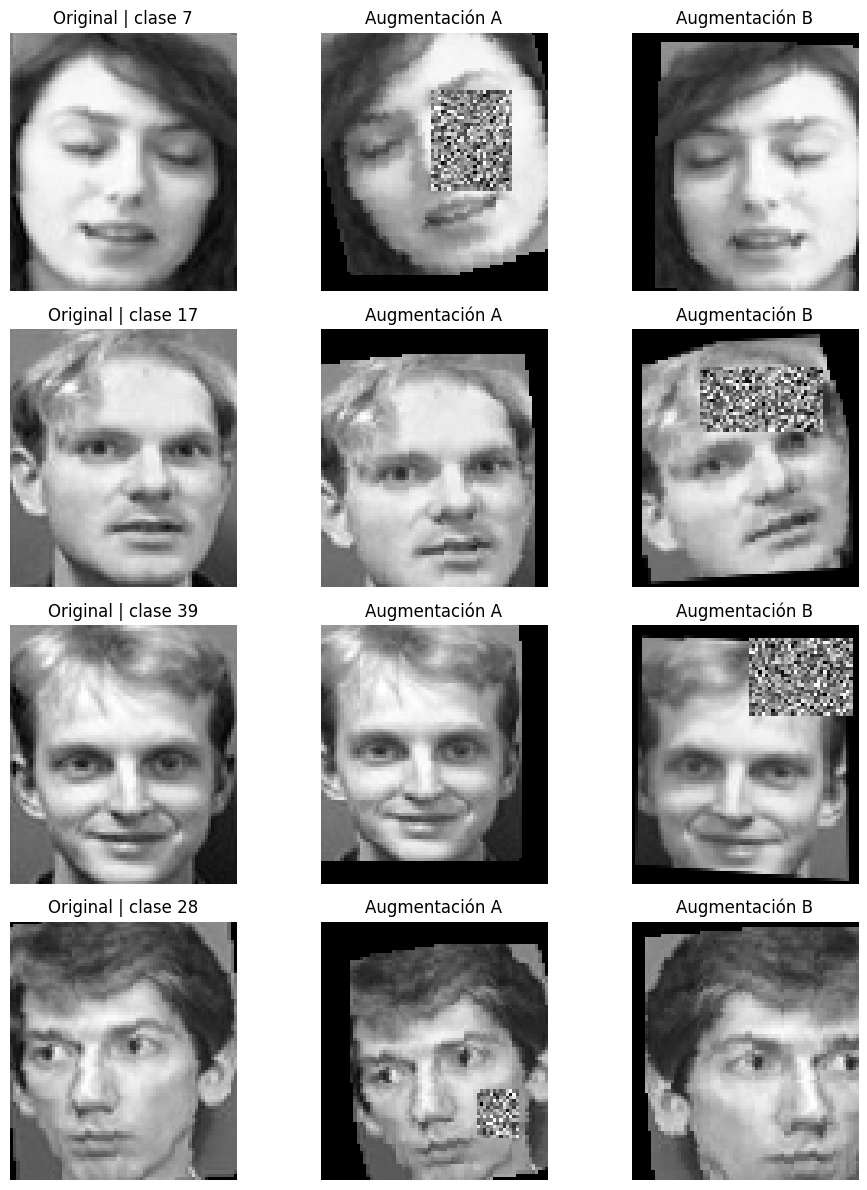

In [4]:
def denormalize(x, mean, std):
    return (x * std + mean).clamp(0, 1)

num_examples = 4
indices = torch.randperm(len(X_train_base))[:num_examples]

fig, axes = plt.subplots(num_examples, 3, figsize=(10, 3 * num_examples))
if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(indices):
    img = X_train_base[idx]
    y = int(Y_train_base[idx])

    aug1 = train_transform(img.clone())
    aug2 = train_transform(img.clone())

    images = [img.squeeze(0).numpy(), denormalize(aug1, train_mean, train_std).squeeze(0).numpy(), denormalize(aug2, train_mean, train_std).squeeze(0).numpy()]
    titles = [f"Original | clase {y}", "Augmentación A", "Augmentación B"]

    for col, (im, t) in enumerate(zip(images, titles)):
        axes[row, col].imshow(im, cmap="gray")
        axes[row, col].set_title(t)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()


## Arquitectura: ResNet (residual + SE)

Se mantiene una estructura por bloques para facilitar modificaciones (stem, bloques residuales, etapas y clasificador).


In [5]:
def conv3x3(in_ch, out_ch, stride=1, groups=1):
    return nn.Conv2d(
        in_ch,
        out_ch,
        kernel_size=3,
        stride=stride,
        padding=1,
        groups=groups,
        bias=False,
    )


def conv1x1(in_ch, out_ch, stride=1):
    return nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False)


def activation_fn(x, activation):
    if activation == "gelu":
        return F.gelu(x)
    return F.silu(x, inplace=True)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(channels, hidden, kernel_size=1)
        self.fc2 = nn.Conv2d(hidden, channels, kernel_size=1)

    def forward(self, x):
        w = self.pool(x)
        w = F.silu(self.fc1(w), inplace=True)
        w = torch.sigmoid(self.fc2(w))
        return x * w


class ResidualSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, drop_prob=0.0, groups=1, activation="silu"):
        super().__init__()

        g1 = groups if (in_ch % groups == 0 and out_ch % groups == 0) else 1
        g2 = groups if (out_ch % groups == 0) else 1

        self.conv1 = conv3x3(in_ch, out_ch, stride=stride, groups=g1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = conv3x3(out_ch, out_ch, stride=1, groups=g2)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.se = SEBlock(out_ch)
        self.dropout = nn.Dropout2d(drop_prob) if drop_prob > 0 else nn.Identity()
        self.activation = activation

        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                conv1x1(in_ch, out_ch, stride=stride),
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = activation_fn(out, self.activation)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)
        out = self.dropout(out)

        out = out + identity
        out = activation_fn(out, self.activation)
        return out


class BetterResNet(nn.Module):
    def __init__(
        self,
        dim_out,
        base_channels=32,
        blocks=(2, 2, 2, 2),
        drop_prob=0.15,
        groups=1,
        activation="silu",
        link_function=lambda x: torch.softmax(x, dim=1),
        loss_function=None,
    ):
        super().__init__()

        self.link = link_function
        self.loss = loss_function if loss_function is not None else nn.CrossEntropyLoss()

        c1 = base_channels
        c2 = c1 * 2
        c3 = c2 * 2
        c4 = c3 * 2

        self.stem = nn.Sequential(
            conv3x3(1, c1, stride=1),
            nn.BatchNorm2d(c1),
            nn.SiLU(inplace=True) if activation == "silu" else nn.GELU(),
        )

        self.layer1 = self._make_layer(c1, c1, blocks[0], stride=1, drop_prob=drop_prob, groups=groups, activation=activation)
        self.layer2 = self._make_layer(c1, c2, blocks[1], stride=2, drop_prob=drop_prob, groups=groups, activation=activation)
        self.layer3 = self._make_layer(c2, c3, blocks[2], stride=2, drop_prob=drop_prob, groups=groups, activation=activation)
        self.layer4 = self._make_layer(c3, c4, blocks[3], stride=2, drop_prob=drop_prob, groups=groups, activation=activation)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head_dropout = nn.Dropout(p=drop_prob)
        self.fc = nn.Linear(c4, dim_out)

    @staticmethod #método sin self ni cls. Se usa para funciones auxiliares dentro de la clase.
    def _make_layer(in_ch, out_ch, n_blocks, stride, drop_prob, groups, activation):
        layers = [ResidualSEBlock(in_ch, out_ch, stride=stride, drop_prob=drop_prob, groups=groups, activation=activation)]
        for _ in range(1, n_blocks):
            layers.append(ResidualSEBlock(out_ch, out_ch, stride=1, drop_prob=drop_prob, groups=groups, activation=activation))
        return nn.Sequential(*layers)

    def operator(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.head_dropout(x)
        x = self.fc(x)
        return x

    def forward_train(self, x, apply_link=False):
        self.train()
        y = self.operator(x)
        return self.link(y) if apply_link else y

    def forward_eval(self, x, apply_link=False):
        self.eval()
        y = self.operator(x)
        return self.link(y) if apply_link else y

    def compute_loss(self, t, y):
        return self.loss(y, t)


## Métricas y función de entrenamiento


In [6]:
def compute_metric_topk(dataloader, model, device, k=3):
    model.eval()
    correct = 0
    topk_correct = 0
    total = 0

    with torch.no_grad():
        for x, t in dataloader:
            x = x.to(device)
            t = t.to(device)
            logits = model.forward_eval(x, apply_link=False)

            pred = logits.argmax(dim=1)
            correct += (pred == t).sum().item()

            topk = torch.topk(logits, k=k, dim=1).indices
            topk_correct += topk.eq(t.view(-1, 1)).any(dim=1).sum().item()
            total += t.size(0)

    acc = correct / total
    topk_acc = topk_correct / total
    global_metric = 0.7 * acc + 0.3 * topk_acc
    return acc, topk_acc, global_metric


def create_loaders(batch_size, num_workers=0):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    train_eval_loader = DataLoader(train_dataset_eval, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, train_eval_loader, test_loader


def train_model(
    model,
    device,
    epochs,
    batch_size,
    lr,
    weight_decay,
    betas,
    eps,
    min_lr,
    grad_clip,
    warmup_epochs,
    mixup_alpha,
    cutmix_alpha,
    mix_probability,
    trial=None,
):
    train_loader, train_eval_loader, test_loader = create_loaders(batch_size=batch_size)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
        betas=betas,
        eps=eps,
    )

    steps_per_epoch = max(1, len(train_loader))
    total_steps = max(1, epochs * steps_per_epoch)
    warmup_steps = max(1, warmup_epochs * steps_per_epoch)
    min_factor = min(1.0, max(min_lr / lr, 1e-4))

    def lr_lambda(step_idx):
        if step_idx < warmup_steps:
            return float(step_idx + 1) / float(warmup_steps)

        progress = float(step_idx - warmup_steps) / float(max(1, total_steps - warmup_steps))
        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        return max(min_factor, cosine)

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    history = {
        "loss": [],
        "lr": [],
        "train_acc": [],
        "test_acc": [],
        "train_top3": [],
        "test_top3": [],
        "train_global": [],
        "test_global": [],
    }

    best_metric = -1.0
    best_epoch = -1
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for x, t in train_loader:
            x = x.to(device)
            t = t.to(device)

            optimizer.zero_grad(set_to_none=True)

            use_mixed_labels = False
            if np.random.rand() < mix_probability and (mixup_alpha > 0 or cutmix_alpha > 0):
                if cutmix_alpha > 0 and (mixup_alpha <= 0 or np.random.rand() < 0.5):
                    x_aug, t_a, t_b, lam = cutmix_batch(x, t, cutmix_alpha)
                else:
                    x_aug, t_a, t_b, lam = mixup_batch(x, t, mixup_alpha)

                y = model.forward_train(x_aug, apply_link=False)
                loss = lam * model.compute_loss(t_a, y) + (1.0 - lam) * model.compute_loss(t_b, y)
                use_mixed_labels = True
            else:
                y = model.forward_train(x, apply_link=False)
                loss = model.compute_loss(t, y)

            loss.backward()

            if grad_clip is not None and grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()
            scheduler.step()

            batch_size_real = t.size(0)
            running_loss += loss.item() * batch_size_real
            n_samples += batch_size_real

        epoch_loss = running_loss / max(1, n_samples)

        train_acc, train_top3, train_global = compute_metric_topk(train_eval_loader, model, device, k=3)
        test_acc, test_top3, test_global = compute_metric_topk(test_loader, model, device, k=3)

        history["loss"].append(epoch_loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["train_top3"].append(train_top3)
        history["test_top3"].append(test_top3)
        history["train_global"].append(train_global)
        history["test_global"].append(test_global)

        if test_global > best_metric:
            best_metric = test_global
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if trial is not None:
            trial.report(test_global, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        print(
            f"Epoch {epoch + 1:03d}/{epochs} | loss={epoch_loss:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.6f} | "
            f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f} | "
            f"test_top3={test_top3:.4f} | test_global={test_global:.4f}"
        )

    print(f"Mejor epoca: {best_epoch} | Mejor global test: {best_metric:.4f}")

    model.load_state_dict(best_state)
    return history, best_epoch, best_metric


## Optuna: búsqueda de hiperparámetros


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def build_model_from_trial(trial):
    base_channels = trial.suggest_categorical("base_channels", [24, 32, 40])
    depth = trial.suggest_categorical("depth", ["2-2-2-2", "2-3-3-2"])
    drop_prob = trial.suggest_float("drop_prob", 0.10, 0.35)
    groups = trial.suggest_categorical("groups", [1, 2, 4])
    activation = trial.suggest_categorical("activation", ["silu", "gelu"])
    label_smoothing = trial.suggest_float("label_smoothing", 0.02, 0.16)

    blocks = tuple(int(x) for x in depth.split("-"))
    loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    model = BetterResNet(
        dim_out=N_CLASSES,
        base_channels=base_channels,
        blocks=blocks,
        drop_prob=drop_prob,
        groups=groups,
        activation=activation,
        link_function=lambda x: torch.softmax(x, dim=1),
        loss_function=loss_fn,
    )
    return model


def objective(trial):
    set_seed(42)

    lr = trial.suggest_float("lr", 5e-5, 2e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 5e-3, log=True)
    beta1 = trial.suggest_float("beta1", 0.85, 0.95)
    beta2 = trial.suggest_float("beta2", 0.97, 0.9995)
    eps = trial.suggest_float("eps", 1e-9, 1e-7, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 24, 32, 48])

    min_lr = trial.suggest_float("min_lr", 1e-6, 3e-4, log=True)
    grad_clip = trial.suggest_float("grad_clip", 0.5, 2.5)
    warmup_epochs = trial.suggest_int("warmup_epochs", 3, 12)

    mixup_alpha = trial.suggest_float("mixup_alpha", 0.0, 0.5)
    cutmix_alpha = trial.suggest_float("cutmix_alpha", 0.0, 1.0)
    mix_probability = trial.suggest_float("mix_probability", 0.3, 0.8)

    model = build_model_from_trial(trial).to(device)

    history, best_epoch, best_metric = train_model(
        model=model,
        device=device,
        epochs=140,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        betas=(beta1, beta2),
        eps=eps,
        min_lr=min_lr,
        grad_clip=grad_clip,
        warmup_epochs=warmup_epochs,
        mixup_alpha=mixup_alpha,
        cutmix_alpha=cutmix_alpha,
        mix_probability=mix_probability,
        trial=trial,
    )

    trial.set_user_attr("best_epoch", int(best_epoch))
    trial.set_user_attr("best_test_acc", float(history["test_acc"][best_epoch]))
    trial.set_user_attr("best_test_top3", float(history["test_top3"][best_epoch]))
    return float(best_metric)


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=20),
)

study.optimize(objective, n_trials=30)

print("Mejor metrica global:", study.best_value)
print("Mejores hiperparametros:", study.best_params)
print("Mejor epoca:", study.best_trial.user_attrs["best_epoch"])
print("Accuracy en esa epoca:", study.best_trial.user_attrs["best_test_acc"])
print("Top-3 en esa epoca:", study.best_trial.user_attrs["best_test_top3"])


[I 2026-04-22 23:18:17,744] A new study created in memory with name: no-name-3f6fe4cd-2d2f-4056-8d1b-4358d73704d1


Device: cuda
Epoch 001/140 | loss=3.7216 | lr=0.000020 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 002/140 | loss=3.7186 | lr=0.000036 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 003/140 | loss=3.6961 | lr=0.000053 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 004/140 | loss=3.6818 | lr=0.000070 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 005/140 | loss=3.7089 | lr=0.000086 | train_acc=0.0000 | test_acc=0.0000 | test_top3=0.0875 | test_global=0.0262
Epoch 006/140 | loss=3.6981 | lr=0.000103 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 007/140 | loss=3.6989 | lr=0.000119 | train_acc=0.0312 | test_acc=0.0500 | test_top3=0.1000 | test_global=0.0650
Epoch 008/140 | loss=3.6920 | lr=0.000136 | train_acc=0.0312 | test_acc=0.0500 | test_top3=0.1250 | test_global=0.0725
Epoch 009/140 | loss=3.6406 | lr=0.

[I 2026-04-22 23:19:21,132] Trial 0 finished with value: 0.7037499999999999 and parameters: {'lr': 0.00019906996673933386, 'weight_decay': 0.0032859708169642424, 'beta1': 0.9231993941811405, 'beta2': 0.9876604252838126, 'eps': 2.0513382630874506e-09, 'batch_size': 32, 'min_lr': 5.675206026988749e-05, 'grad_clip': 0.5411689885916049, 'warmup_epochs': 12, 'mixup_alpha': 0.41622132040021087, 'cutmix_alpha': 0.21233911067827616, 'mix_probability': 0.3909124836035503, 'base_channels': 40, 'depth': '2-2-2-2', 'drop_prob': 0.2529632236805949, 'groups': 4, 'activation': 'gelu', 'label_smoothing': 0.047954329502170365}. Best is trial 0 with value: 0.7037499999999999.


Epoch 140/140 | loss=2.1705 | lr=0.000057 | train_acc=0.6813 | test_acc=0.6500 | test_top3=0.8000 | test_global=0.6950
Mejor epoca: 138 | Mejor global test: 0.7037
Epoch 001/140 | loss=3.7280 | lr=0.000044 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 002/140 | loss=3.7203 | lr=0.000081 | train_acc=0.0125 | test_acc=0.0375 | test_top3=0.0750 | test_global=0.0488
Epoch 003/140 | loss=3.7147 | lr=0.000118 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 004/140 | loss=3.7183 | lr=0.000156 | train_acc=0.0375 | test_acc=0.0375 | test_top3=0.0750 | test_global=0.0488
Epoch 005/140 | loss=3.7107 | lr=0.000193 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 006/140 | loss=3.6607 | lr=0.000230 | train_acc=0.0187 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 007/140 | loss=3.6521 | lr=0.000267 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epo

[I 2026-04-22 23:20:12,867] Trial 1 finished with value: 0.815 and parameters: {'lr': 0.00033327629473929517, 'weight_decay': 0.00015535445807588442, 'beta1': 0.8546450412719997, 'beta2': 0.9879225731310924, 'eps': 2.19304855566437e-09, 'batch_size': 32, 'min_lr': 5.682837558512262e-06, 'grad_clip': 0.6953442280127677, 'warmup_epochs': 9, 'mixup_alpha': 0.22007624686980065, 'cutmix_alpha': 0.12203823484477883, 'mix_probability': 0.5475884550556351, 'base_channels': 32, 'depth': '2-2-2-2', 'drop_prob': 0.23001700529445268, 'groups': 4, 'activation': 'gelu', 'label_smoothing': 0.14527582905987083}. Best is trial 1 with value: 0.815.


...

Epoch 140/140 | loss=1.6503 | lr=0.000075 | train_acc=0.9875 | test_acc=0.9375 | test_top3=0.9875 | test_global=0.9525
Mejor epoca: 126 | Mejor global test: 0.9612
Epoch 001/140 | loss=3.7143 | lr=0.000018 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 002/140 | loss=3.7121 | lr=0.000033 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 003/140 | loss=3.6726 | lr=0.000049 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 004/140 | loss=3.6604 | lr=0.000064 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0625 | test_global=0.0362
Epoch 005/140 | loss=3.6297 | lr=0.000079 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0625 | test_global=0.0362
Epoch 006/140 | loss=3.5527 | lr=0.000094 | train_acc=0.0750 | test_acc=0.0500 | test_top3=0.1500 | test_global=0.0800
Epoch 007/140 | loss=3.5332 | lr=0.000106 | train_acc=0.0750 | test_acc=0.0625 | test_top3=0.1750 | test_global=0.0963
Epo

[I 2026-04-22 23:32:07,603] Trial 14 finished with value: 0.9312499999999999 and parameters: {'lr': 0.00010635027174649131, 'weight_decay': 1.629474168622277e-05, 'beta1': 0.9050569445800319, 'beta2': 0.985088539778944, 'eps': 1.090927467458814e-08, 'batch_size': 32, 'min_lr': 1.591254966712571e-05, 'grad_clip': 1.4656972929227845, 'warmup_epochs': 7, 'mixup_alpha': 0.360493717481525, 'cutmix_alpha': 0.4430159415609196, 'mix_probability': 0.5004831188261248, 'base_channels': 40, 'depth': '2-2-2-2', 'drop_prob': 0.10192728418071982, 'groups': 1, 'activation': 'gelu', 'label_smoothing': 0.030487938358669153}. Best is trial 9 with value: 0.97875.


Epoch 140/140 | loss=1.4568 | lr=0.000016 | train_acc=0.9938 | test_acc=0.9125 | test_top3=0.9750 | test_global=0.9312
Mejor epoca: 137 | Mejor global test: 0.9312
Epoch 001/140 | loss=3.7074 | lr=0.000094 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 002/140 | loss=3.6949 | lr=0.000179 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 003/140 | loss=3.6928 | lr=0.000264 | train_acc=0.0500 | test_acc=0.0625 | test_top3=0.1750 | test_global=0.0963
Epoch 004/140 | loss=3.6289 | lr=0.000349 | train_acc=0.0437 | test_acc=0.0500 | test_top3=0.1875 | test_global=0.0912
Epoch 005/140 | loss=3.5727 | lr=0.000435 | train_acc=0.0563 | test_acc=0.0625 | test_top3=0.1375 | test_global=0.0850
Epoch 006/140 | loss=3.5124 | lr=0.000520 | train_acc=0.0563 | test_acc=0.0625 | test_top3=0.1625 | test_global=0.0925
Epoch 007/140 | loss=3.4429 | lr=0.000605 | train_acc=0.0500 | test_acc=0.0500 | test_top3=0.1750 | test_global=0.0875
Epo

[W 2026-04-22 23:32:48,504] Trial 15 failed with parameters: {'lr': 0.0010225077055700722, 'weight_decay': 1.0216607532793861e-06, 'beta1': 0.8736388062059577, 'beta2': 0.9753672892754555, 'eps': 5.661848257387078e-08, 'batch_size': 16, 'min_lr': 1.4562048660408152e-05, 'grad_clip': 0.9069271418227233, 'warmup_epochs': 12, 'mixup_alpha': 0.14919006483248853, 'cutmix_alpha': 0.621260925263226, 'mix_probability': 0.3148275055959643, 'base_channels': 40, 'depth': '2-3-3-2', 'drop_prob': 0.2939741843681186, 'groups': 1, 'activation': 'silu', 'label_smoothing': 0.1111529873705025} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\mimor\Documents\Universidad\2025-2026\Redes Neuronales\RedesNeuronales\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\mimor\AppData\Local\Temp\ipykernel_19676\3965023048.py", line 49, in objective
    history, best_epoch, best_metric = tr

KeyboardInterrupt: 

## Reentrenamiento final con los mejores hiperparámetros


In [ ]:
best = study.best_params
print("Hiperparametros optimos:", best)

blocks = tuple(int(x) for x in best["depth"].split("-"))
final_loss = nn.CrossEntropyLoss(label_smoothing=best["label_smoothing"])

final_model = BetterResNet(
    dim_out=N_CLASSES,
    base_channels=best["base_channels"],
    blocks=blocks,
    drop_prob=best["drop_prob"],
    groups=best["groups"],
    activation=best["activation"],
    link_function=lambda x: torch.softmax(x, dim=1),
    loss_function=final_loss,
).to(device)

final_history, final_best_epoch, final_best_metric = train_model(
    model=final_model,
    device=device,
    epochs=300,
    batch_size=best["batch_size"],
    lr=best["lr"],
    weight_decay=best["weight_decay"],
    betas=(best["beta1"], best["beta2"]),
    eps=best["eps"],
    min_lr=best["min_lr"],
    grad_clip=best["grad_clip"],
    warmup_epochs=best["warmup_epochs"],
    mixup_alpha=best["mixup_alpha"],
    cutmix_alpha=best["cutmix_alpha"],
    mix_probability=best["mix_probability"],
    trial=None,
)
torch.save(final_model.state_dict(), "resnet18_4_0.pth")


## Resumen y gráficas


In [ ]:
print(f"Mejor época final: {final_best_epoch}")
print(f"Mejor test global final: {final_best_metric:.4f}")
print(f"Accuracy test en mejor época: {final_history['test_acc'][final_best_epoch]:.4f}")
print(f"Top-3 test en mejor época: {final_history['test_top3'][final_best_epoch]:.4f}")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8, 16))

ax1.plot(final_history['loss'], linestyle='--')
ax1.set_ylabel('Cross entropy loss')
ax1.set_xlabel('epochs')
ax1.legend(['loss'])

ax2.plot(final_history['train_acc'], linestyle='--')
ax2.plot(final_history['test_acc'], linestyle='--')
ax2.set_ylim([0.0, 1.0])
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('epochs')
ax2.legend(['train_acc', 'test_acc'])

ax3.plot(final_history['train_top3'], linestyle='--')
ax3.plot(final_history['test_top3'], linestyle='--')
ax3.set_ylim([0.0, 1.0])
ax3.set_ylabel('Top-3')
ax3.set_xlabel('epochs')
ax3.legend(['train_top3', 'test_top3'])

ax4.plot(final_history['train_global'], linestyle='--')
ax4.plot(final_history['test_global'], linestyle='--')
ax4.set_ylim([0.0, 1.0])
ax4.set_ylabel('0.7*acc + 0.3*top3')
ax4.set_xlabel('epochs')
ax4.legend(['train_global', 'test_global'])

plt.tight_layout()
plt.show()


## Matriz de probabilidades sobre test


In [ ]:
_, _, test_loader = create_loaders(batch_size=32)

n_test = len(test_dataset)
matriz_probs = torch.zeros((n_test, N_CLASSES), dtype=torch.float32)

final_model.eval()
index = 0
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        logits = final_model.forward_eval(x, apply_link=False)
        probs = torch.softmax(logits, dim=1).cpu()

        b = probs.size(0)
        matriz_probs[index:index + b] = probs
        index += b

print("Shape matriz_probs:", matriz_probs.shape)
print(matriz_probs)

matriz_probs_np = matriz_probs.numpy()
print("Shape matriz_probs_np:", matriz_probs_np.shape)
